# House Price Prediction

Predict house prices using regression models and feature engineering.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("../data/train.csv")

test = pd.read_csv("../data/test.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
print(train.shape)
print(test.shape)

(1460, 81)
(1459, 80)


## 
Train and test datasets loaded successfully.

In [4]:
train.info()
train.isnull().sum().sort_values(ascending=False).head(20)

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

## 
Several columns contain missing values that require preprocessing.

## EDA

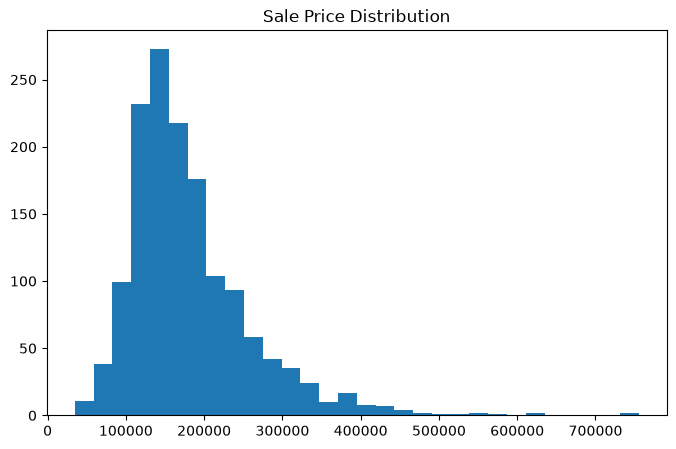

In [5]:
plt.figure(figsize=(8,5))

plt.hist(train["SalePrice"], bins=30)

plt.title("Sale Price Distribution")

plt.show()

## 
House prices are right-skewed.

In [9]:
#Correlation
corr = train.corr(numeric_only=True)

top = corr["SalePrice"].sort_values(ascending=False).head(10)

top


SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

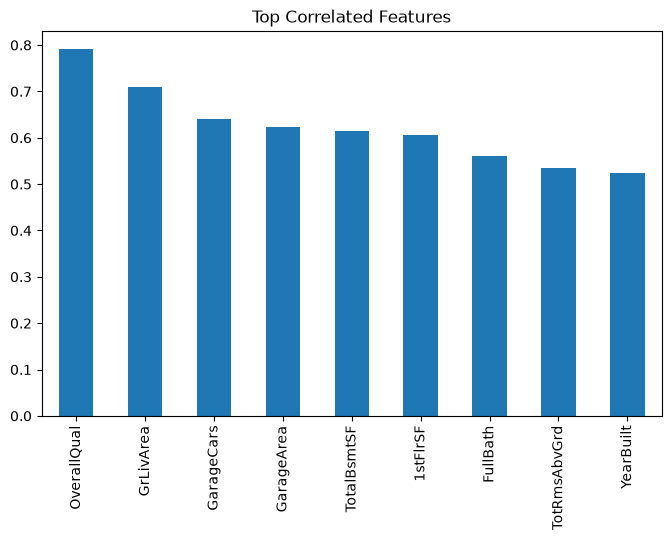

In [10]:
#Plot
top.drop("SalePrice").plot.bar(figsize=(8,5))

plt.title("Top Correlated Features")

plt.show()

Overall Quality and Living Area have the strongest positive correlation with Sale Price.

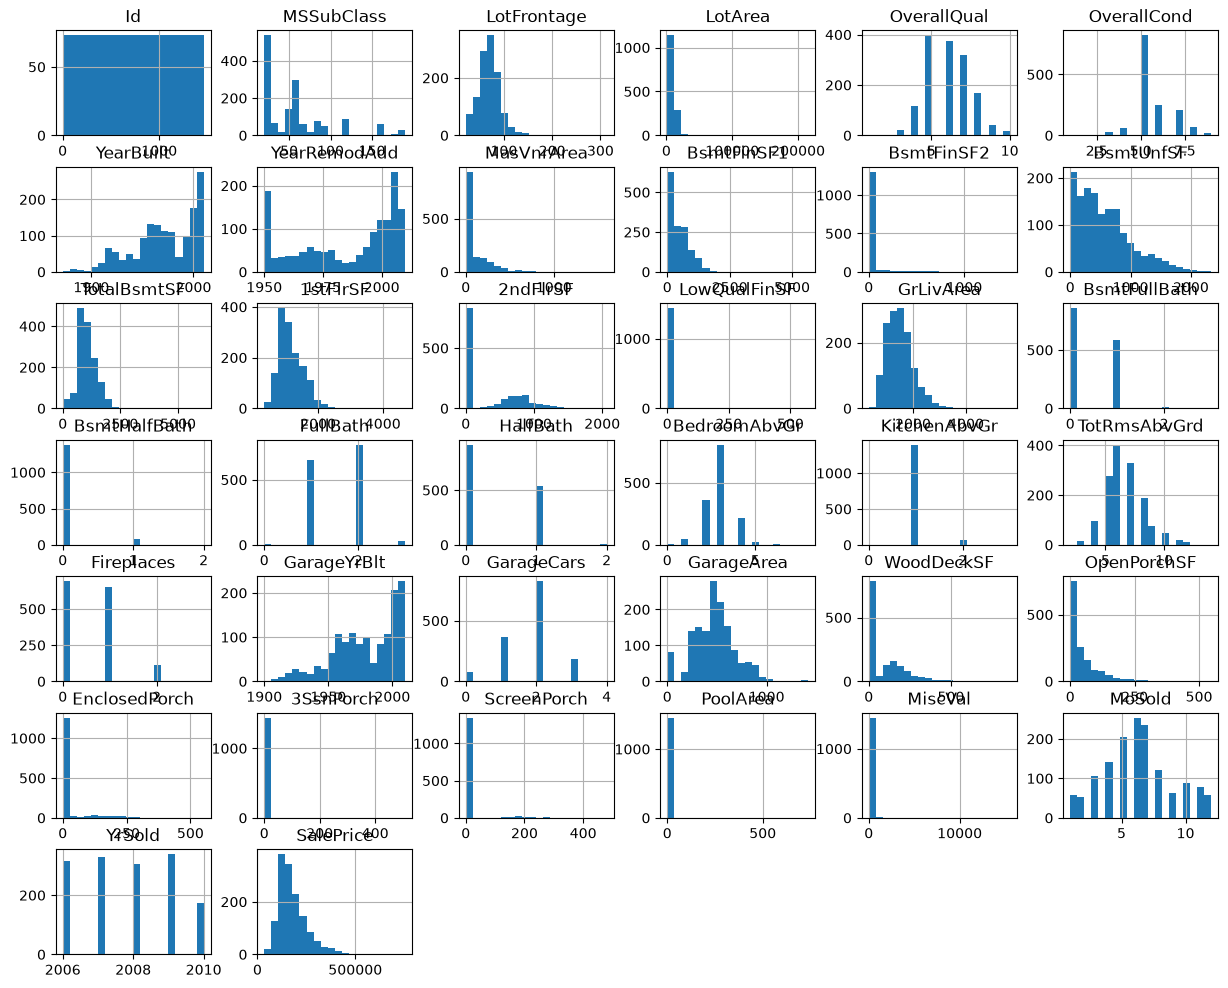

In [11]:
#Numeric Histograms
train.hist(
    figsize=(15,12),
    bins=20
)

plt.show()

## Data Preprocessing

In [12]:
#Target
X = train.drop("SalePrice", axis=1)

y = train["SalePrice"]

In [13]:
#Numeric Columns
num_cols = X.select_dtypes(include=["int64","float64"]).columns

In [15]:
#Categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns

In [16]:
#Pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [17]:
#Column Transformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [18]:
#Train Test Split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Training Models
We'll compare three models: Random Forest, Gradient Boosting, XGBoost

In [19]:
models = {

    "Random Forest":
        RandomForestRegressor(random_state=42),

    "Gradient Boosting":
        GradientBoostingRegressor(random_state=42),

    "XGBoost":
        XGBRegressor(random_state=42)

}

results = {}

best_model = None

best_score = -999

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train,y_train)

    pred = pipe.predict(X_valid)

    score = r2_score(y_valid,pred)

    results[name]=score

    print(name,score)

    if score>best_score:

        best_score=score

        best_model=pipe

Random Forest 0.8941513442361082
Gradient Boosting 0.9047864953287394
XGBoost 0.8967649936676025


## 
The model with the highest R² score is selected for prediction.

In [21]:
#Predictions
predictions = best_model.predict(test)

#Submission 
submission = pd.DataFrame({

    "Id":test["Id"],

    "SalePrice":predictions

})

submission.head()

#Save
submission.to_csv(
    "../outputs/submission.csv",
    index=False
)

print("Submission Saved")

Submission Saved


## Feature Importance

In [22]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":best_model.named_steps["model"].feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,num__OverallQual,0.512999
16,num__GrLivArea,0.141745
26,num__GarageCars,0.044101
12,num__TotalBsmtSF,0.040687
9,num__BsmtFinSF1,0.033393
14,num__2ndFlrSF,0.029122
13,num__1stFlrSF,0.028555
3,num__LotArea,0.018122
246,cat__GarageFinish_Unf,0.016674
181,cat__BsmtQual_Ex,0.014884


## 
OverallQual, GrLivArea, GarageCars, and TotalBsmtSF are among the strongest predictors of house price.

In [30]:
#Save Outputs

results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "R2 Score": list(results.values())
})

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

results_df

,Model,R2 Score
1,Gradient Boosting,0.904786
2,XGBoost,0.896765
0,Random Forest,0.894151


In [28]:
results_df.to_csv(
    "../outputs/model_comparison.csv",
    index=False
)

print("Model Comparison Saved!")

Model Comparison Saved!
